# Bonus Components

## Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Final Clusters

In [16]:
df_clustering = pd.read_csv("../cluster_data/final_clusters.csv").set_index("Loyalty#")
df_categorical = pd.read_csv("../cluster_data/categorical_features.csv").set_index("Loyalty#")

1. Introduction & Setup
2. Load Final Clusters
3. Financial Impact Modeling
   - CLV proxy
   - ROI analysis
4. Fuzzy Clustering
   - c-means
   - membership analysis
5. Key Visualizations
6. Summary of Insights

## 1. Financial Impact Modeling

In [19]:
df_bonus = df_clustering.merge(
    df_categorical,
    on="Loyalty#",
    how="left"
)

In [28]:
clv_distribution = pd.crosstab(
        df_bonus["merged_labels"],
        df_bonus["CLV_Bins"],
        normalize="index"
    )

clv_distribution

CLV_Bins,High,Low,Medium
merged_labels,,,
0,0.353860,0.301517,0.344623
1,0.325965,0.348607,0.325429
2,0.286254,0.380665,0.333082
3,0.321081,0.335135,0.343784
4,0.339529,0.332094,0.328377
5,0.340013,0.319973,0.340013


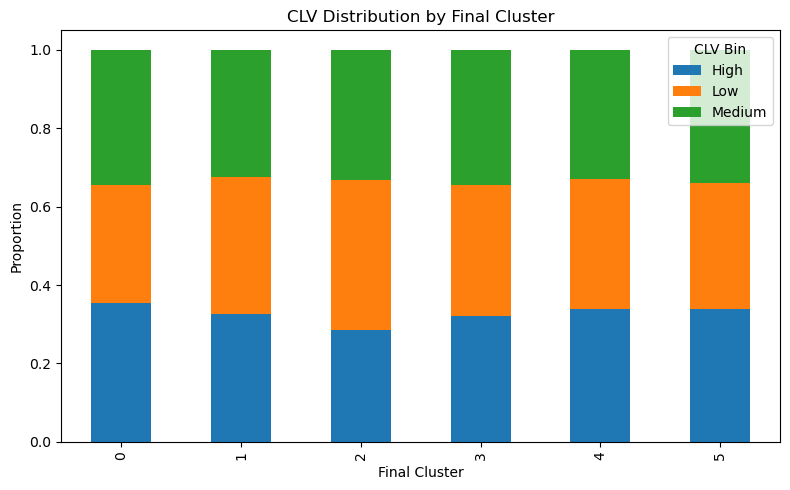

In [29]:
clv_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("CLV Distribution by Final Cluster")
plt.ylabel("Proportion")
plt.xlabel("Final Cluster")
plt.legend(title="CLV Bin")
plt.tight_layout()
plt.show()


In [25]:
clv_map = {"Low": 1, "Medium": 2, "High": 3}
df_bonus["CLV_score"] = df_bonus["CLV_Bins"].map(clv_map)

cluster_value = (
    df_bonus
    .groupby("merged_labels")
    .agg(
        avg_clv_score=("CLV_score", "mean"),
        size=("CLV_score", "count")
    )
    .sort_values("avg_clv_score", ascending=False)
)

cluster_value

,avg_clv_score,size
merged_labels,,
0,2.052342,4547
5,2.020040,1497
4,2.007435,807
3,1.985946,925
1,1.977358,7464
2,1.905589,1324


In [35]:
q1 = cluster_value["avg_clv_score"].quantile(0.33)
q2 = cluster_value["avg_clv_score"].quantile(0.66)

def assign_priority(x):
    if x >= q2:
        return "High priority"
    elif x >= q1:
        return "Medium priority"
    else:
        return "Low priority"

cluster_value["priority"] = cluster_value["avg_clv_score"].apply(assign_priority)

cluster_value

,avg_clv_score,cluster_size,priority
merged_labels,,,
0,2.052342,4547,High priority
5,2.020040,1497,High priority
4,2.007435,807,Medium priority
3,1.985946,925,Medium priority
1,1.977358,7464,Low priority
2,1.905589,1324,Low priority


In [36]:
assumptions = {
    "High priority":   {"cost": 8, "lift": 0.05},
    "Medium priority": {"cost": 5, "lift": 0.03},
    "Low priority":    {"cost": 2, "lift": 0.01},
}

In [37]:
roi_table = cluster_value.copy()

roi_table["cost_per_customer"] = roi_table["priority"].map(
    lambda x: assumptions[x]["cost"]
)

roi_table["expected_lift"] = roi_table["priority"].map(
    lambda x: assumptions[x]["lift"]
)

roi_table["customers_targeted"] = roi_table["cluster_size"]

roi_table["expected_benefit"] = (
    roi_table["avg_clv_score"] *
    roi_table["expected_lift"] *
    roi_table["customers_targeted"]
)

roi_table["expected_cost"] = (
    roi_table["cost_per_customer"] *
    roi_table["customers_targeted"]
)

roi_table["ROI"] = (
    (roi_table["expected_benefit"] - roi_table["expected_cost"]) /
    roi_table["expected_cost"]
)

roi_table.sort_values("ROI", ascending=False)


,avg_clv_score,cluster_size,priority,cost_per_customer,expected_lift,customers_targeted,expected_benefit,expected_cost,ROI
merged_labels,,,,,,,,,
0,2.052342,4547,High priority,8,0.05,4547,466.60,36376,-0.987173
5,2.020040,1497,High priority,8,0.05,1497,151.20,11976,-0.987375
4,2.007435,807,Medium priority,5,0.03,807,48.60,4035,-0.987955
3,1.985946,925,Medium priority,5,0.03,925,55.11,4625,-0.988084
1,1.977358,7464,Low priority,2,0.01,7464,147.59,14928,-0.990113
2,1.905589,1324,Low priority,2,0.01,1324,25.23,2648,-0.990472


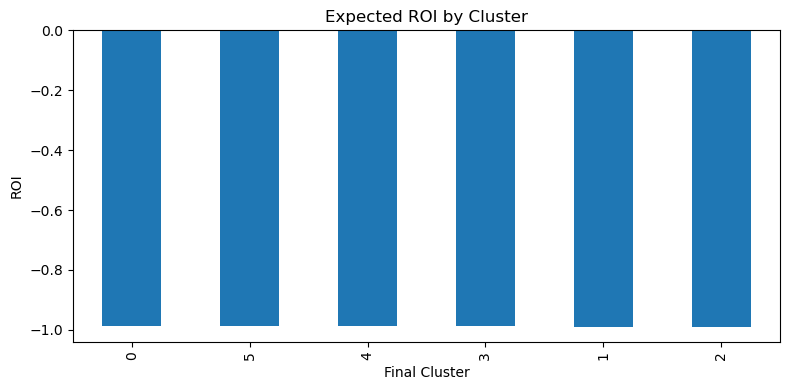

In [38]:
roi_table["ROI"].plot(kind="bar", figsize=(8, 4))
plt.title("Expected ROI by Cluster")
plt.ylabel("ROI")
plt.xlabel("Final Cluster")
plt.tight_layout()
plt.show()


In [39]:
timeline = roi_table[[
    "priority",
    "avg_clv_score",
    "cluster_size",
    "ROI"
]].copy()

timeline


,priority,avg_clv_score,cluster_size,ROI
merged_labels,,,,
0,High priority,2.052342,4547,-0.987173
5,High priority,2.020040,1497,-0.987375
4,Medium priority,2.007435,807,-0.987955
3,Medium priority,1.985946,925,-0.988084
1,Low priority,1.977358,7464,-0.990113
2,Low priority,1.905589,1324,-0.990472


## 2. Fuzzy Clustering Implementation